In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize

import kwant
from scipy import linalg as la
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function

from tqdm import tqdm

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 11,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)


def dos_at_fermi(energies, fermi_energy, broadening):
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    return np.mean(norm_lorenzian)

In [27]:
import sys, os

data_name = "data/full_phase_diagram_20_n_V0.pickle"

with open(data_name, "rb") as f:
    data = pickle.load(f)
with open("analysis/voronoi_20.pickle", "rb") as f:
    lattice = pickle.load(f)

In [ ]:
fillings = data["filling"]
J_vals = data["J"]


avg_mags = np.zeros([len(fillings), len(J_vals)])
energies = np.zeros([len(fillings), len(J_vals), lattice.n_vertices * 4])

for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        current_data = data["params"][i, j]

        avg_mags[i, j] = np.mean(current_data["m"])

        ham = alt_hamiltonian(
            lattice,
            current_data["t1"],
            current_data["t2"],
            current_data["J"],
            current_data["U"],
            current_data["m"],
            current_data["n"],
        )

        energies[i, j] = la.eigvalsh(ham)


data["params"][0, 0].keys()

100%|██████████| 31/31 [06:57<00:00, 13.48s/it]


dict_keys(['t1', 't2', 'J', 'U', 'filling', 'theta_offset', 'm', 'n'])

100%|██████████| 31/31 [00:00<00:00, 1496.52it/s]


(31, 41) (31, 41) (31, 41) (31, 41)


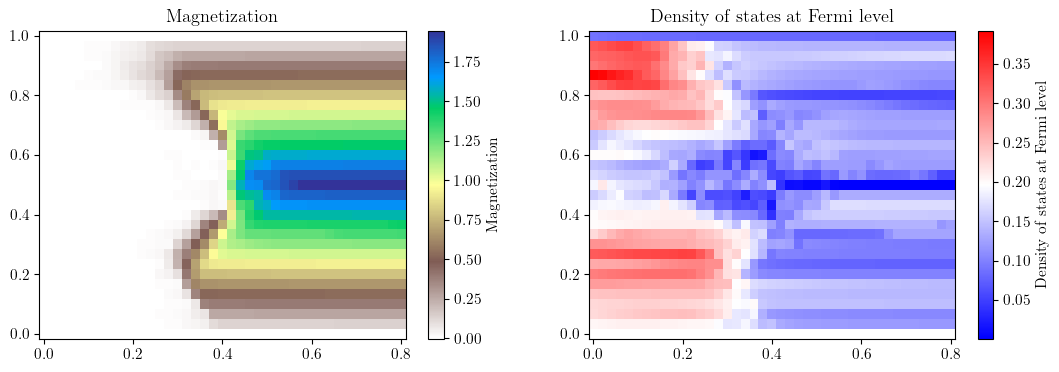

In [49]:
broadening = 0.01
dos_vals = np.zeros([len(fillings), len(J_vals)])
# size in MB
sys.getsizeof(energies) / 1024 / 1024
for i, filling in enumerate(tqdm(fillings)):
    for j, J in enumerate(J_vals):

        e = energies[i, j]

        fermi_energy = np.mean(e[int(filling * len(e)) - 1 : int(filling * len(e)) + 1])
        # print(e)
        dos_vals[i, j] = dos_at_fermi(e, fermi_energy, broadening).real


J, FIL = np.meshgrid(J_vals, fillings)
print(FIL.shape, J.shape, avg_mags.shape, dos_vals.shape)


fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].pcolor(J, FIL, avg_mags, cmap="terrain_r")
ax[1].pcolor(J, FIL, dos_vals, cmap="bwr")
ax[0].set_title("Magnetization")
ax[1].set_title("Density of states at Fermi level")


# add colorbars
cbar = fig.colorbar(ax[0].pcolormesh(J, FIL, avg_mags, cmap="terrain_r"), ax=ax[0])
cbar.set_label("Magnetization")
cbar = fig.colorbar(ax[1].pcolormesh(J, FIL, dos_vals, cmap="bwr"), ax=ax[1])
cbar.set_label("Density of states at Fermi level")

plt.show()